In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

# Load Dataset
df = pd.read_csv('StudentsPerformance.csv')
print("Dimensi Data Awal:", df.shape)

Dimensi Data Awal: (1000, 8)


In [2]:
# Ekstraksi fitur numerik sebagai representasi Ruang Vektor R^3
X = df[['math score', 'reading score', 'writing score']].values

# Normalisasi data (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Contoh representasi vektor (5 baris pertama) setelah normalisasi:")
print(X_scaled[:5])

Contoh representasi vektor (5 baris pertama) setelah normalisasi:
[[ 0.39002351  0.19399858  0.39149181]
 [ 0.19207553  1.42747598  1.31326868]
 [ 1.57771141  1.77010859  1.64247471]
 [-1.25954302 -0.83389925 -1.58374436]
 [ 0.65395415  0.60515772  0.45733301]]


In [3]:
# Menerapkan algoritma K-Means (Euclidean distance default)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_

# Menyimpan hasil label cluster ke dataframe
df['Cluster'] = labels

# Denormalisasi centroid untuk interpretasi yang lebih mudah dibaca
centroids_original = scaler.inverse_transform(centroids)

# Mengubah bentuk array menjadi DataFrame agar rapi
centroid_df = pd.DataFrame(np.round(centroids_original, 2), columns=['Math', 'Reading', 'Writing'])
centroid_df.insert(0, 'Cluster', ['Cluster 0', 'Cluster 1', 'Cluster 2'])

print("DATA KOORDINAT CENTROID FINAL per cluster:")
display(centroid_df)

DATA KOORDINAT CENTROID FINAL per cluster:


,Cluster,Math,Reading,Writing
0,Cluster 0,65.34,68.46,67.82
1,Cluster 1,48.10,50.67,48.49
2,Cluster 2,81.71,85.15,84.21


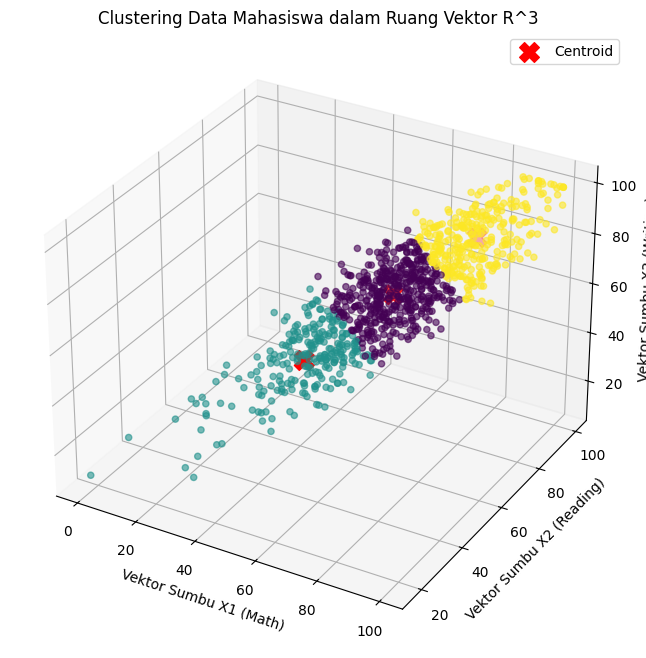

In [4]:
# Setup plot 3 dimensi
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot dari titik vektor
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=df['Cluster'], cmap='viridis', alpha=0.6)

# Plot Centroid
ax.scatter(centroids_original[:, 0], centroids_original[:, 1], centroids_original[:, 2], 
           c='red', marker='X', s=200, label='Centroid')

ax.set_xlabel('Vektor Sumbu X1 (Math)')
ax.set_ylabel('Vektor Sumbu X2 (Reading)')
ax.set_zlabel('Vektor Sumbu X3 (Writing)')
ax.set_title('Clustering Data Mahasiswa dalam Ruang Vektor R^3')
plt.legend()
plt.show()

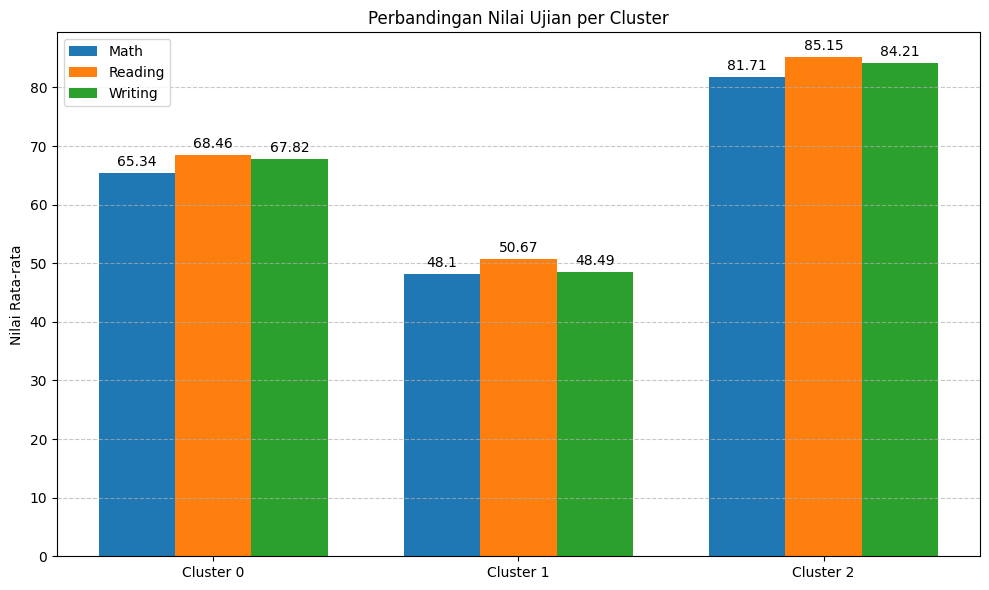

In [5]:
# Setup data untuk Bar Chart
x = np.arange(len(centroid_df['Cluster']))  # Lokasi label cluster di sumbu X
width = 0.25  # Lebar masing-masing bar

fig, ax = plt.subplots(figsize=(10, 6))

# Membuat bar untuk masing-masing bidang ujian
bar1 = ax.bar(x - width, centroid_df['Math'], width, label='Math', color='#1f77b4')
bar2 = ax.bar(x, centroid_df['Reading'], width, label='Reading', color='#ff7f0e')
bar3 = ax.bar(x + width, centroid_df['Writing'], width, label='Writing', color='#2ca02c')

# Kustomisasi tampilan grafik
ax.set_ylabel('Nilai Rata-rata')
ax.set_title('Perbandingan Nilai Ujian per Cluster')
ax.set_xticks(x)
ax.set_xticklabels(centroid_df['Cluster'])
ax.legend()

# Menambahkan label angka persis di atas setiap bar
ax.bar_label(bar1, padding=3)
ax.bar_label(bar2, padding=3)
ax.bar_label(bar3, padding=3)

# Menampilkan grafik
plt.grid(axis='y', linestyle='--', alpha=0.7)
fig.tight_layout()
plt.show()